In [202]:
#Import Neccesary Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [203]:
# Load the dataset
data = pd.read_csv('DataSet/ChurnData.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [204]:
# Confirm the shape of the dataset and print the column names
print("Dataset shape:" ,str(data.shape))
print("Dataset columns:")
for col in data.columns:
    print(col)

Dataset shape: (7043, 21)
Dataset columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [205]:
#Observe the data Types of each column
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [206]:
# check for missing values in the dataset
print("Number of Missing values in the dataset:")
print(data.isnull().sum())

Number of Missing values in the dataset:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [207]:
# since Customer-Id Didn't play any role in the prediction of churn, we can drop it from the dataset
data.drop('customerID', axis=1, inplace=True)

In [208]:
#check for duplicate values in the dataset
print("Number of Duplicate values in the dataset:",data.duplicated().sum())

Number of Duplicate values in the dataset: 22


In [209]:
# Drop duplicate values
data.drop_duplicates(inplace=True)
print("Number of Duplicate values in the dataset after dropping duplicates:",data.duplicated().sum())


Number of Duplicate values in the dataset after dropping duplicates: 0


In [210]:
# Transform the data types of the columns to appropriate types 

# since TotalCharges is a numerical column but it is stored as an str type, we need to convert it to float type
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
#check for missing values in the dataset after converting TotalCharges to float type
print("Number of missing values in TotalCharges after conversion:", data['TotalCharges'].isnull().sum())


Number of missing values in TotalCharges after conversion: 11


In [211]:
# since the % of missing values is Not significant We can drop them.
data.dropna(inplace=True)
print("Number of Missing values : ",data.isnull().sum().sum())

Number of Missing values :  0


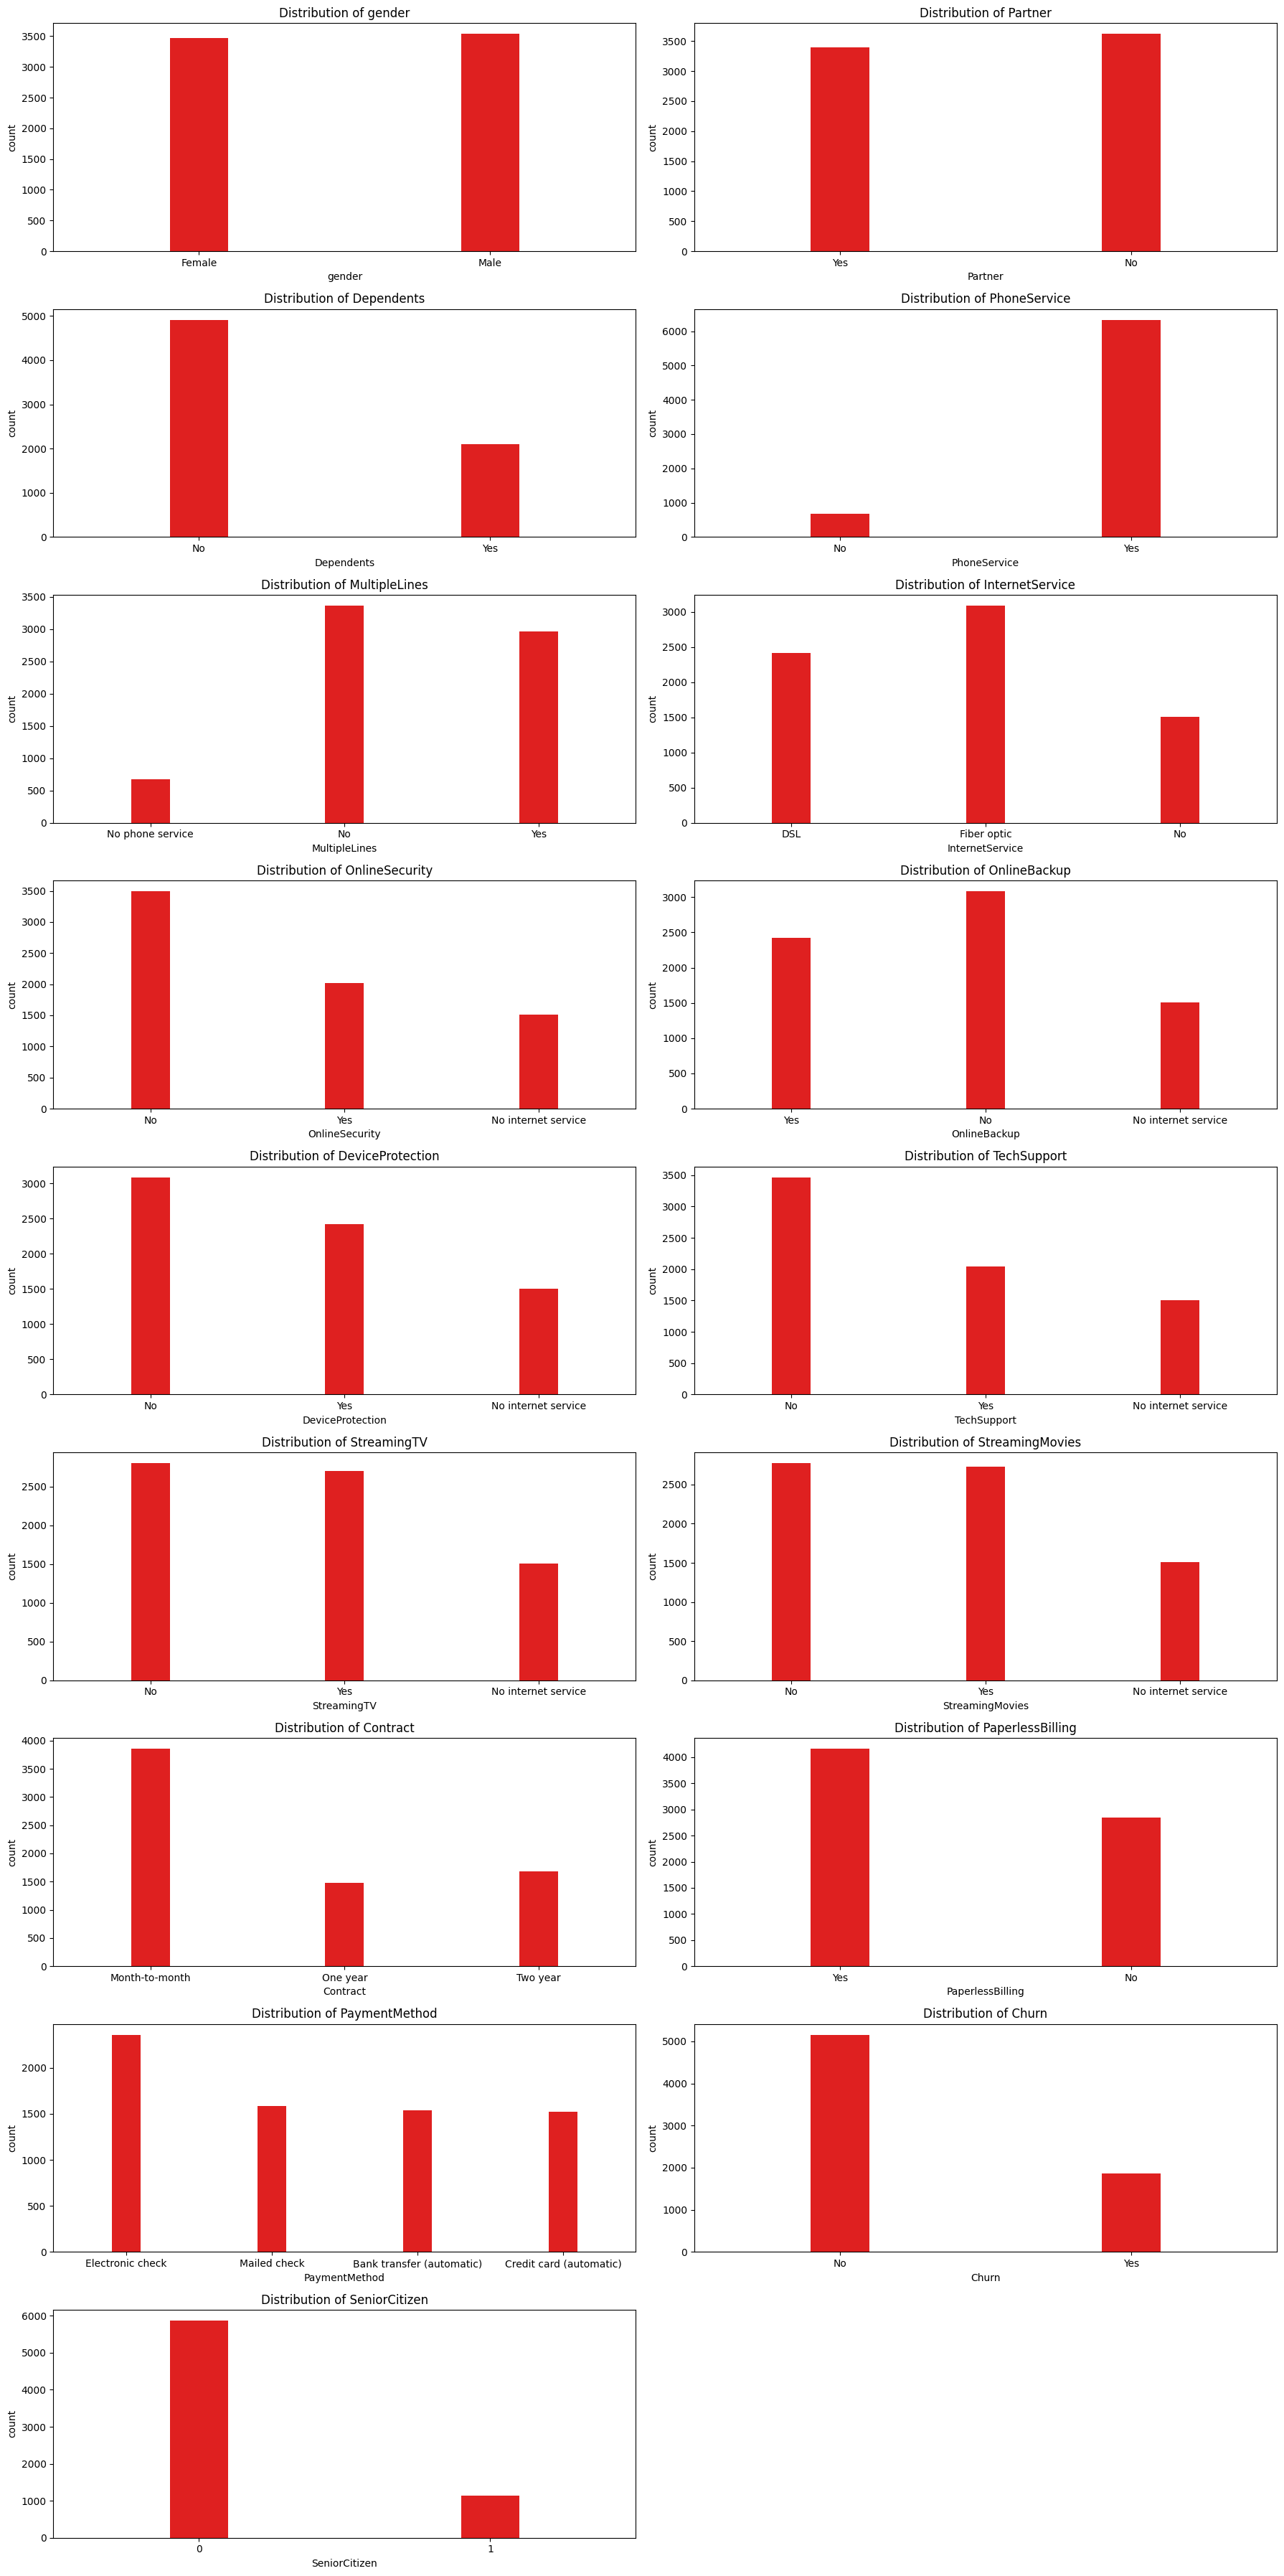

In [212]:
import math
categorical_cols = [col for col in data.columns if data[col].dtype == "str"]
categorical_cols.append('SeniorCitizen') 
num_cols = 2 
num_rows = math.ceil(len(categorical_cols) / num_cols)

plt.figure(figsize=(18, 4 * num_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.countplot( x=data[col], color="red",width=0.2)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

categorical_cols.remove('SeniorCitizen')


In [213]:
# Transform the data types of the columns to appropriate types using one-hot encoding for categorical variables.
data = pd.get_dummies(data,columns=categorical_cols, drop_first=True).astype(int)

print("Dataset shape after one-hot encoding:" ,data.shape)
print("Dataset columns after one-hot encoding:")
print(data.columns)


Dataset shape after one-hot encoding: (7010, 31)
Dataset columns after one-hot encoding:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='str')


In [214]:
#Re-name churn_Yes to Churn for better understanding
data = data.rename(columns={'Churn_Yes': 'Churn'})

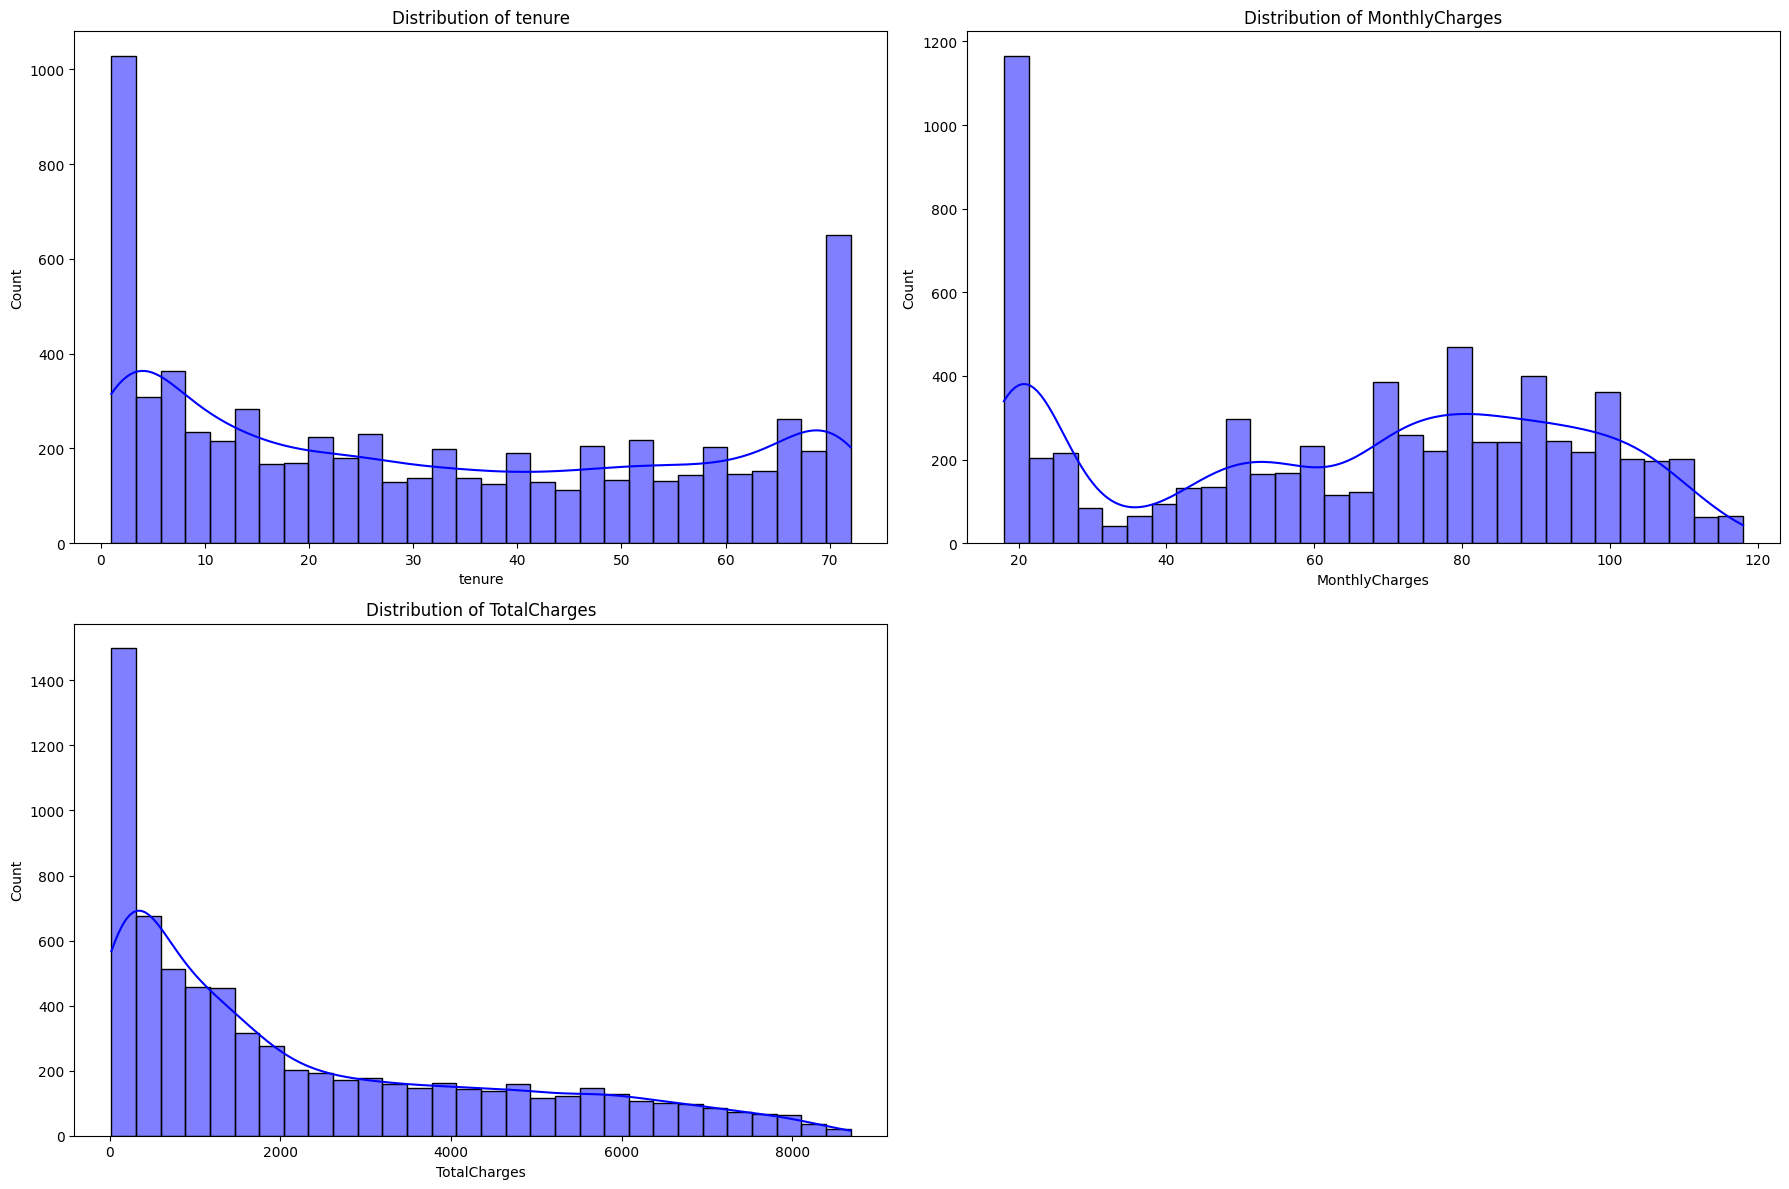

In [223]:
# Plot the distributions for tenure, MonthlyCharges, and TotalCharges columns using histograms
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(18, 12))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[col], kde=True, color="blue", bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [224]:
def IQR_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if outliers.empty:
        print(f"No outliers found in {column}.")
        return pd.DataFrame() 
    else:
        print(f"Outliers in {column}:")
        print(outliers)
        return outliers

No outliers found in tenure.


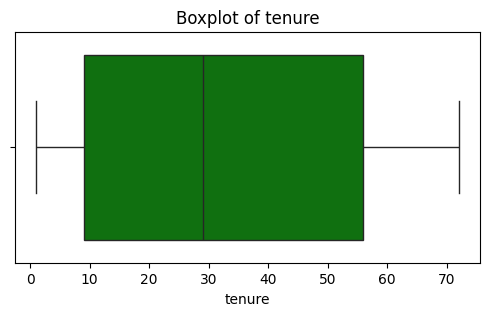

No outliers found in MonthlyCharges.


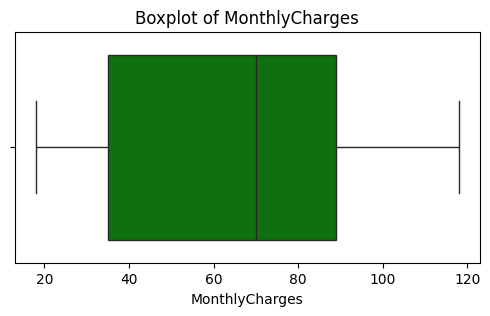

No outliers found in TotalCharges.


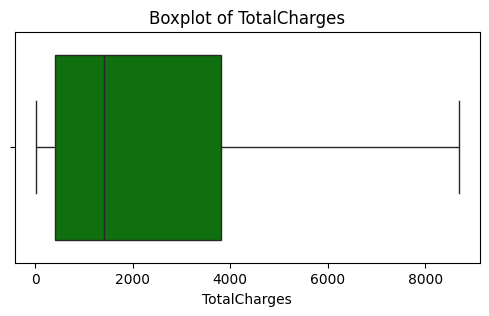

In [225]:
# Do a Outliner Checks for this Continuous RV 
for col in continuous_cols:
    IQR_outliers(data, col)
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col], color="green")
    plt.title(f"Boxplot of {col}")
    plt.show()

In [227]:
#save the cleaned dataset to a new CSV file
data.to_csv('DataSet/ChurnData_prepared.csv', index=False)
